In [1]:
import sys
#sys.path.append("/user/work/ef17148/oldstuff/ef17148/.conda/envs/GCN_env/lib/python3.8/site-packages/")
#sys.path.insert(0, "/user/work/ef17148/oldstuff/ef17148/.conda/envs/graphnet/lib/python3.8/site-packages/")

#import cartopy
#import cartopy.crs as ccrs
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches

import numpy as np

#sys.path.insert(0, "/user/work/ef17148/oldstuff/ef17148/.conda/envs/GCN_env/lib/python3.8/site-packages/")

#sys.path.insert(0,"/software/local/languages/miniforge3/envs/tensorflow/lib/python3.12/site-packages")

sys.path.insert(0,"/software/local/languages/miniforge3/envs/elena/lib/python3.12/site-packages/")

sys.path.insert(0,"/user/work/ef17148/oldstuff/ef17148/.conda/envs/new_graphnet/lib/python3.12/site-packages")

print(sys.path)

import torch
import os
import pickle
import einops

#import plenoptic as po

sys.path.insert(0, "/user/work/ef17148/GCN/graphnet/")
sys.path.insert(1, "/user/work/ef17148/GCN/graphnet/graphnet_LPDM_emulator/")
from graphnet_LPDM_emulator.model.layers.encoder import *
from graphnet_LPDM_emulator.model.layers.decoder import *
from graphnet_LPDM_emulator.model.layers.processor import *
from graphnet_LPDM_emulator.model.layers.graph_net_block import *
from graphnet_LPDM_emulator.model.data.dataloader_graphnet import *
from graphnet_LPDM_emulator.model.data.load_data import *
from graphnet_LPDM_emulator.model.forecast import GraphSatelliteForecaster
from graphnet_LPDM_emulator.model.loss_functions import *
from graphnet_LPDM_emulator.model.evaluation import *

import torch.optim as optim
from sklearn.metrics import mean_squared_error, r2_score
import time
from datetime import datetime
import json
import argparse

import random

%load_ext autoreload
%autoreload 2
import warnings
warnings.filterwarnings("ignore", category=RuntimeWarning)

import timeit

['/user/work/ef17148/oldstuff/ef17148/.conda/envs/new_graphnet/lib/python3.12/site-packages', '/software/local/languages/miniforge3/envs/elena/lib/python3.12/site-packages/', '/user/work/ef17148/oldstuff/ef17148/.conda/envs/new_graphnet/lib/python312.zip', '/user/work/ef17148/oldstuff/ef17148/.conda/envs/new_graphnet/lib/python3.12', '/user/work/ef17148/oldstuff/ef17148/.conda/envs/new_graphnet/lib/python3.12/lib-dynload', '', '/user/home/ef17148/.local/lib/python3.12/site-packages', '__editable__.openghg_inversions-0.2.0.finder.__path_hook__', '/user/work/ef17148/oldstuff/ef17148/.conda/envs/new_graphnet/lib/python3.12/site-packages']


# comparing the losses across models

In [27]:
# four models to compare, each with a different seed 
# note that they all do have the same parameters even if the first is called _B, it was just an error in naming!!
loss_weiB = get_loss("satellite_clever2_50_[6,12]_vB_logv3_weightedbytruth_B")
loss_weiB["name"] = "Seed 34"
loss_weiC5 = get_loss("satellite_clever2_50_[6,12]_vB_logv3_weightedbytruth_assym_C_seed5")
loss_weiC5["name"] = "Seed 5"
loss_weiC100 = get_loss("satellite_clever2_50_[6,12]_vB_logv3_weightedbytruth_assym_C_seed100")
loss_weiC100["name"] = "Seed 100"
loss_weiC33 = get_loss("satellite_clever2_50_[6,12]_vB_logv3_weightedbytruth_assym_C_seed33")
loss_weiC33["name"] = "Seed 33"

loading last checkpoint for satellite_clever2_50_[6,12]_vB_logv3_weightedbytruth_B
loading last checkpoint for satellite_clever2_50_[6,12]_vB_logv3_weightedbytruth_assym_C_seed5
loading last checkpoint for satellite_clever2_50_[6,12]_vB_logv3_weightedbytruth_assym_C_seed100
loading last checkpoint for satellite_clever2_50_[6,12]_vB_logv3_weightedbytruth_assym_C_seed33


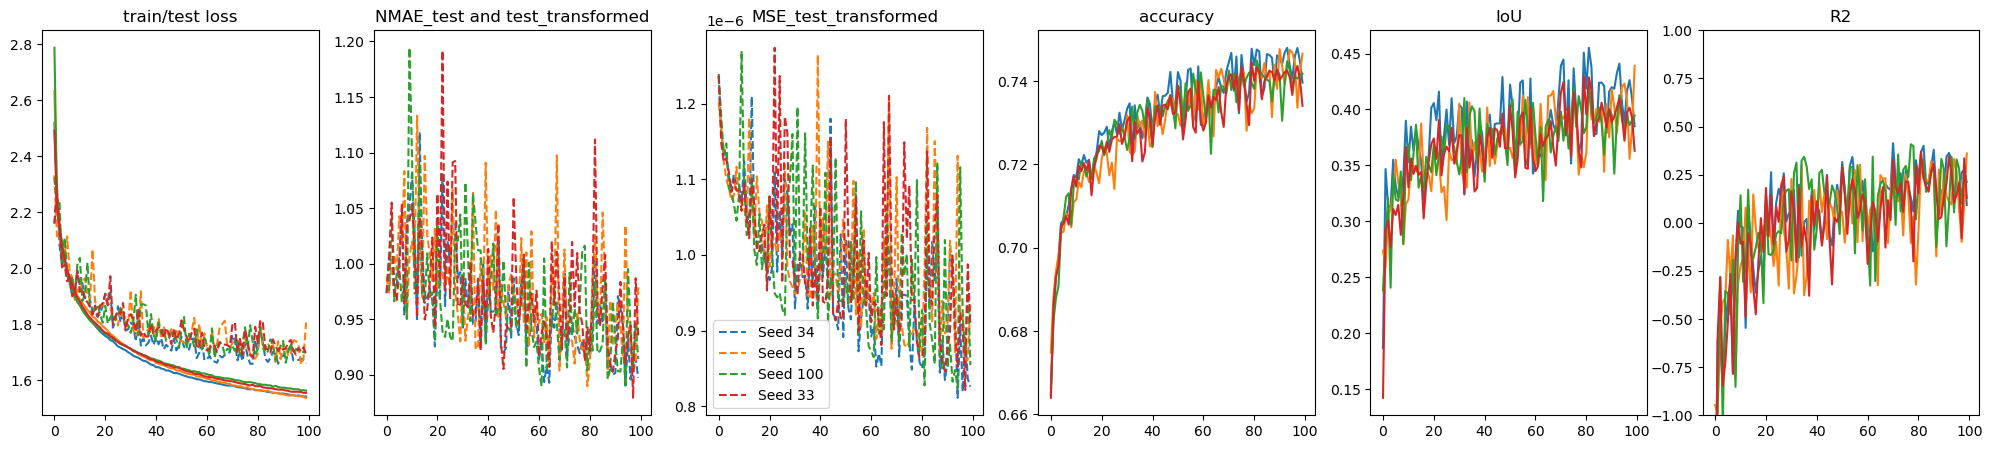

In [28]:
models_to_plot = [loss_weiB, loss_weiC5, loss_weiC100, loss_weiC33]
fig, ax = plt.subplots(1,6, figsize = (25,5))
for mod in models_to_plot:
    if "train" in list(mod.keys()):
        p, = ax[0].plot(mod["train"][:100])
        ax[0].plot(mod["test"][:100], "--", c=p.get_color()) 
    #if "NMAE_test" in list(mod.keys()):
    #    ax[1].plot(abs(np.array(mod["NMAE_test"])), c=p.get_color())  
    if "NMAE_test_transformed" in list(mod.keys()):
        ax[1].plot(abs(np.array(mod["NMAE_test_transformed"]))[:100], "--", c=p.get_color())       
    if "MSE_test_transformed" in list(mod.keys()):
        ax[2].plot(abs(np.array(mod["MSE_test_transformed"]))[:100], "--", c=p.get_color(), label=mod["name"])    
    if "accuracy" in list(mod.keys()):
        ax[3].plot(abs(np.array(mod["accuracy"]))[:100], c=p.get_color())    
    if "IoU" in list(mod.keys()):
        ax[4].plot(abs(np.array(mod["IoU"]))[:100], c=p.get_color())   
    if "flux_uniform" in list(mod.keys()):
        ax[5].plot(mod["flux_uniform"]["R2"][:100], c=p.get_color())   
    

ax[0].set_title("train/test loss")
ax[1].set_title("NMAE_test and test_transformed")
ax[2].set_title("MSE_test_transformed")
ax[3].set_title("accuracy")
ax[4].set_title("IoU")
ax[5].set_title("R2")
ax[5].set_ybound(-1,1)
ax[2].legend()

# loading the data for one of the models

In [2]:
model_name = "satellite_clever2_50_[6,12]_vB_logv3_weightedbytruth_assym_C_seed5"
mod = ModelEv(model_name, size=50, validation_set="0[1-3]", test_set="*", val_year="2016", test_year="2016", check_validation_overlap=True)
# loads the model into a ModelEv object. by default it has the parameters above, which validate on Jan-March (stored in mod.preds_val) and keeps the rest in mod.preds_test 
# setting "check_validation_overlap=False" will keep all the footprints in mod.preds_test

loading data from /user/work/ef17148/GCN/graphnet/graph_weather/trained_satellite_models_fixedmet/satellite_clever2_50_[[]6,12[]]_vB_logv3_weightedbytruth_assym_C_seed5/predictions/preds_2016*.nc
using validation data: 20160[1-3] and test data: 2016*. Checking overlap between the two: True


/user/work/ef17148/oldstuff/ef17148/.conda/envs/new_graphnet/lib/python3.12/site-packages/xarray/core/indexing.py:1443: PerformanceWarning: Slicing with an out-of-order index is generating 311 times more chunks
  return self.array[key]


In [3]:
"""
mod.preds_test has a naming structure (i acknowledge, confusing):
- fps: the original footprints (native data space)
- trans_fp: the original footprints, transformed according to the input transform (transformed data space)
- predictions: the predictions of the model, untouched (transformed data space)
- trans_predictions: the predictions of the model, transformed back to the original data space (native data space)
"""
mod.preds_test

<xarray.Dataset>
Dimensions:            (time: 4243, lat: 50, lon: 50)
Coordinates:
  * time               (time) datetime64[ns] 2016-04-01T15:29:20 ... 2016-12-...
  * lat                (lat) int64 0 1 2 3 4 5 6 7 8 ... 42 43 44 45 46 47 48 49
  * lon                (lon) int64 0 1 2 3 4 5 6 7 8 ... 42 43 44 45 46 47 48 49
Data variables:
    predictions        (time, lat, lon) float32 -2.114 -2.18 ... 0.1506 0.5178
    trans_predictions  (time, lat, lon) float32 6.109e-07 ... 0.0003045
    fp                 (time, lat, lon) float64 6.866e-05 ... 0.0002823
    trans_fp           (time, lat, lon) float32 -0.1285 -0.0415 ... 0.4849
Attributes:
    creation_date:  2024-02-11 15:41:59.635325

In [4]:
# threshold the model to remove the lower values. stores these predictions in mod.pred_fluxes["thr"]
mod.get_adjusted_models(which="thr_only")

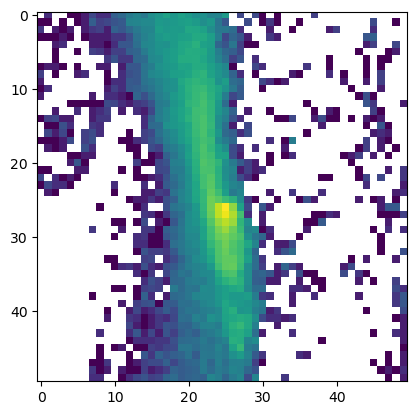

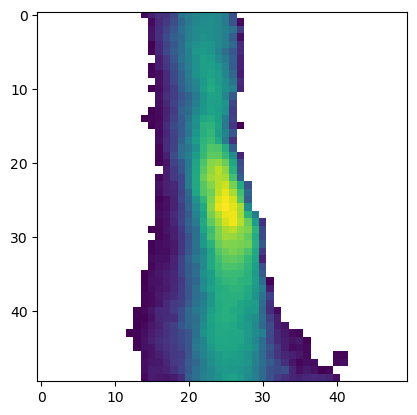

In [11]:
t = 16#t+5
plt.imshow(np.log10(mod.preds_test.fp[t]))
plt.show()
plt.imshow(np.log10(mod.preds_test.thr[t]))
plt.show()

In [13]:
# get fluxes by default calculates uniform fluxes, ie summing over the footprints
mod.get_fluxes()

using UNIFORM fluxes!
USING NO UNITS TRANSFORM on the fluxes! this may have changed


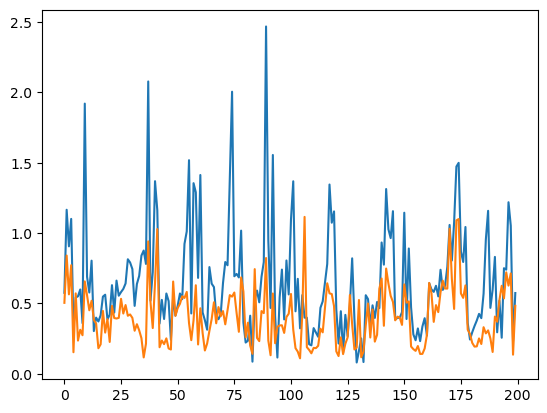

In [14]:
window_n = 5
window_size = 200
plt.plot(mod.true_flux[window_n*window_size:(1+window_n)*window_size])
plt.plot(mod.pred_fluxes["thr"][window_n*window_size:(1+window_n)*window_size])

In [15]:
# OR we can load and cut the actual fluxes to get realistic above-baseline concentrations

# loads the brazil map of fluxes
brazil_fluxes = load_default_brazil_emissions()

# load the true footprints to use the release_lat and release_lon,
# and select the same timepoints as the testing set
true_fps = load_fps("/group/chemistry/acrg/LPDM/fp_NAME_pre20210701/SOUTHAMERICA/*BRAZIL*SOUTHAMERICA_2016*.nc")
true_fps = true_fps.sel(time=mod.preds_test.time)

cut_flux = cut_emissions_data(brazil_fluxes, true_fps, 50)
cut_flux = cut_flux.transpose([2,0,1])
# now cut_flux is in the same shape as mod.pred_fluxes["thr"], so we can plot it

In [16]:
mod.get_fluxes(cut_flux)

USING NO UNITS TRANSFORM on the fluxes! this may have changed


Text(0, 0.5, 'ppb')

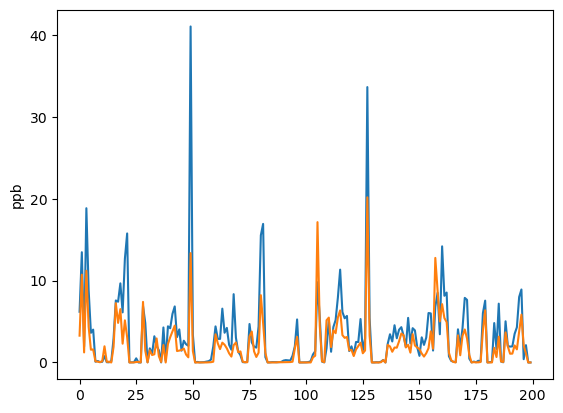

In [20]:
window_n = 3#window_n+1
window_size = 200
plt.plot(1e9*mod.true_flux[window_n*window_size:(1+window_n)*window_size])
plt.plot(1e9*mod.pred_fluxes["thr"][window_n*window_size:(1+window_n)*window_size])
plt.ylabel("ppb")